In [1]:
import os
import sys
os.chdir('..')
# sys.path.insert('.')

In [2]:
import argparse
import os
import time
import torch
import pandas as pd
from importlib import reload
import json
import numpy as np
from dotenv import load_dotenv
from copy import deepcopy
import glob
import re
import ast
import json
from ast import literal_eval
load_dotenv()

True

In [3]:
os.environ['CUDA_VISIBLE_DEVICES'] = '7'

In [4]:
from transformer_lens import HookedTransformer, HookedTransformerConfig
import pickle
# Automatically select device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
def load_finetuned_model_lens_from_dir(dir: str, device: str = device) -> HookedTransformer:
    """
    Load a fine-tuned TransformerLens model from a specified directory.

    Args:
        dir (str): Directory containing the model files.
        device (str): Device to load the model onto.
    
    Returns:
        HookedTransformer: The loaded TransformerLens model.
    """
    with open(os.path.join(dir, 'model_config.pkl'), 'rb') as f:
        new_cfg_dict = pickle.load(f)
    new_cfg = HookedTransformerConfig.from_dict(new_cfg_dict)
    new_model = HookedTransformer(new_cfg)
    new_model.load_state_dict(torch.load(os.path.join(dir, 'model.pt'), map_location=device))
    return new_model

/raid/home/m13521157/absa-eap-ig/enveap/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Get Counterfacts from Test Data

In [5]:
# List all files in a directory recursively, but stop at the last folder before a file
def list_files_recursively(directory):
	file_list = []
	for root, dirs, files in os.walk(directory):
		for file in files:
			file_list.append(os.path.join(root, file))
	return file_list

In [6]:
from typing import List, Dict
import re
def parse_absa_string(text: str) -> List[Dict[str, str]]:
    """
    Parses a string formatted as "[A] aspect [O] opinion [S] sentiment" into a list of dictionaries.
    Each dictionary contains the tag as the key and the corresponding value.
    For example, "[A] [O] [S] [A] harga [O] terjangkau [S] positive [SSEP] [A] fasilitas [O] nyaman [S] positive" becomes:
    [{'A': 'harga', 'S': 'positive', 'O': 'terjangkau'},
    {'A': 'fasilitas', 'S': 'positive', 'O': 'nyaman'}].

    Args:
        text (str): ABSA string output to be parsed.

    Returns:
        List[Dict[str, str]]: List of dictionaries of parsed ABSA output.

    """
    pattern = r"\[(\w+)\]\s*([^[]+)"
    matches = re.findall(pattern, text)

    result = []
    current_dict = {}

    for tag, content in matches:
        if tag == "SSEP":  # Sentence separator -> Start a new dictionary
            result.append(current_dict)
            current_dict = {}
        else:
            current_dict[tag] = content.strip()

    if current_dict:  # Append the last sentence if it exists
        result.append(current_dict)

    return result

### Get the candidates

#### Load dataset

In [7]:
lang = 'indo'
dataset_folder = 'corrected_splitopinion_typocorrected'
seed = 123
model_path_parent = f'outputs/models/eap/{dataset_folder}/circuit-{lang}_finetune-{lang}/seed_{seed}'
dataset_path = f'hotel_dataset/counterfacts/{dataset_folder}/{lang}_counterfacts.csv'
filtered_data_path = f'test/{lang}_debug_filtered.csv'
full_aos_path = f'test/{lang}_debug_full_aos.csv'
sequence_variants_path = f'test/{lang}_debug_sequence_variant.csv'
eap_output_path = f'test/{lang}_debug_eap_dataset.csv'
langs = ['indo']
counterfact_id = 'counterfactsv3.3_adamw'

In [8]:
files = list_files_recursively(f'outputs/modelsadamw/eap/{dataset_folder}')
models = [os.path.dirname(f) for f in files if 'topk' not in f]
models = [f for f in models if not f.endswith('full_sft')]
models = list(set(models))
models

['outputs/modelsadamw/eap/corrected_splitopinion_typocorrected/circuit-indo_finetune-indo/seed_9584/aos_sequence_variants/full_sft/2025-10-11 20:42:23.538158_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20',
 'outputs/modelsadamw/eap/corrected_splitopinion_typocorrected/circuit-indo_finetune-indo/seed_2024/aos_sequence_variants/full_sft/2025-10-12 04:59:46.888449_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20',
 'outputs/modelsadamw/eap/corrected_splitopinion_typocorrected/circuit-indo_finetune-indo/seed_777/aos_sequence_variants/full_sft/2025-10-12 04:59:50.449884_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20',
 'outputs/modelsadamw/eap/corrected_splitopinion_typocorrected/circuit-indo_finetune-indo/seed_31415/aos_sequence_variants/full_sft/2025-10-12 04:59:45.215811_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-2

In [9]:
dataset_dict = {}
for lang in langs:
    with open(f'hotel_dataset/{lang}/{dataset_folder}/hotel_aste_train_augmented_noreasoning.json', 'r') as f:
        dataset_dict[lang] = json.load(f)

#### Get valid candidates (n number of triples with no null aspects)

In [10]:
valid_candidate = {}
if 'aos' in dataset_folder or 'gas' in dataset_folder:
	step = 1
else:
	step = 5
for lang in langs:
	valid_candidate[lang] = []
	for idx in range(0, len(dataset_dict[lang]), step):
		num_of_targets = re.findall(r'\[SSEP\]', dataset_dict[lang][idx]['target'])

		# Initialize the number of triplets deemed valid
		valid_num_of_targets = [0] # List of valid number of targets
		if len(num_of_targets) in valid_num_of_targets and 'null' not in dataset_dict[lang][idx]['target']:
			valid_candidate[lang].append(dataset_dict[lang][idx])

len(valid_candidate['indo'])

191

#### Get valid candidates (n number of triplets, no null aspects, less replacement)

In [9]:
model = HookedTransformer.from_pretrained('Qwen/Qwen2.5-0.5B', device=device)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loaded pretrained model Qwen/Qwen2.5-0.5B into HookedTransformer


In [52]:
valid_candidate = {}
for lang in langs:
	valid_candidate[lang] = []
	for idx in range(0, len(dataset_dict[lang])):
		num_of_targets = re.findall(r'\[SSEP\]', dataset_dict[lang][idx]['target'])

		# Initialize the number of triplets deemed valid
		valid_num_of_targets = [0] # List of valid number of targets
		if len(num_of_targets) in valid_num_of_targets and 'null' not in dataset_dict[lang][idx]['target']:
			valid_candidate[lang].append(dataset_dict[lang][idx])

len(valid_candidate['indo'])

191

In [53]:
df = pd.DataFrame(valid_candidate['indo'])

In [54]:
df['input_tokens_count'] = df['input'].apply(lambda x: len(model.to_str_tokens(x.replace('[A] [O] [S]', '').strip())))

In [58]:
df['target_parsed'] = df['target'].apply(lambda x: parse_absa_string(x))

def count_aspect_and_opinion_tokens(list_of_triplets):
	count = 0
	for triplet in list_of_triplets:
		if triplet['A'] in triplet['O']: # Count only the tokens length of O part if A in O
			count += len(model.to_str_tokens(f" {triplet['O']}"))
		else:
			count += len(model.to_str_tokens(f" {triplet['A']}")) + len(model.to_str_tokens(f" {triplet['O']}"))
	return count
df['ao_tokens_count'] = df['target_parsed'].apply(lambda x: count_aspect_and_opinion_tokens(x))

In [59]:
df['ratio_ao_to_input'] = df['ao_tokens_count'] / df['input_tokens_count']

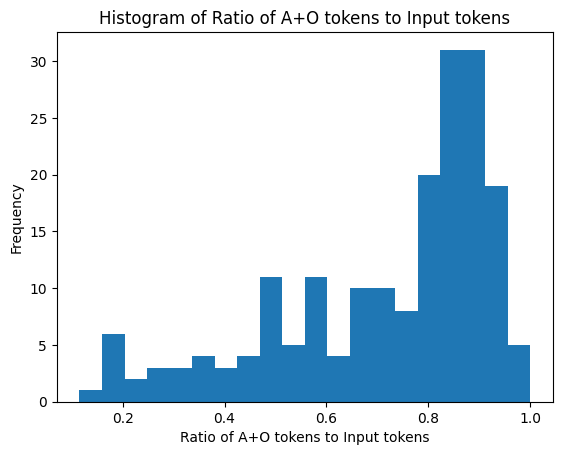

In [61]:
# Plot histogram of ratio_ao_to_input
import matplotlib.pyplot as plt
plt.hist(df['ratio_ao_to_input'], bins=20)
plt.xlabel('Ratio of A+O tokens to Input tokens')
plt.ylabel('Frequency')
plt.title('Histogram of Ratio of A+O tokens to Input tokens')
plt.show()

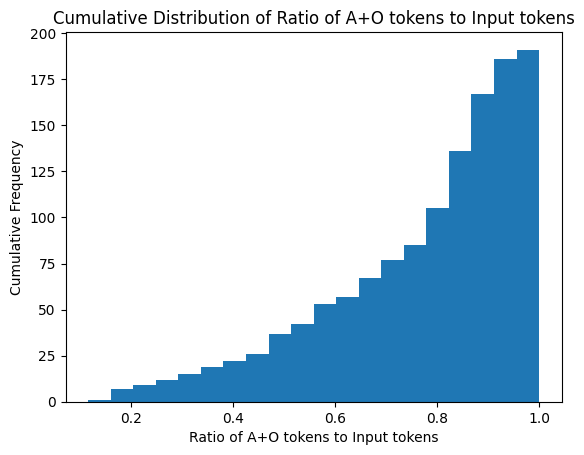

In [67]:
# Plot cumulative distribution of ratio_ao_to_input (the y label should be the true frequency)
plt.hist(df['ratio_ao_to_input'], bins=20, cumulative=True, density=False)
plt.xlabel('Ratio of A+O tokens to Input tokens')
plt.ylabel('Cumulative Frequency')
plt.title('Cumulative Distribution of Ratio of A+O tokens to Input tokens')
plt.show()

In [65]:
df['valid'] = df['ratio_ao_to_input'].apply(lambda x: x < 0.7)
df['valid'].value_counts()

valid
False    124
True      67
Name: count, dtype: int64

In [11]:
model.to_str_tokens("Hotel ini sangat bagus dan pelayanannya ramah. [SSEP] Hotel ini sangat buruk dan pelayanannya lambat. [SSEP] Hotel ini biasa saja dan pelayanannya standar.")

['Hotel',
 ' ini',
 ' sangat',
 ' bag',
 'us',
 ' dan',
 ' p',
 'elay',
 'an',
 'annya',
 ' ram',
 'ah',
 '.',
 ' [',
 'S',
 'SEP',
 ']',
 ' Hotel',
 ' ini',
 ' sangat',
 ' bur',
 'uk',
 ' dan',
 ' p',
 'elay',
 'an',
 'annya',
 ' lamb',
 'at',
 '.',
 ' [',
 'S',
 'SEP',
 ']',
 ' Hotel',
 ' ini',
 ' bias',
 'a',
 ' saja',
 ' dan',
 ' p',
 'elay',
 'an',
 'annya',
 ' stand',
 'ar',
 '.']

#### Output the final dataset

In [15]:
for lang in langs:
    data_for_csv = {
        'index': [instance['sentence_id'] for instance in valid_candidate[lang]],
        'original_pair': [f"{instance['input']} {instance['target']}" for instance in valid_candidate[lang]],
	}
    df_empty_counterfact = pd.DataFrame(data_for_csv)
    # df_empty_counterfact['corrupted_pair'] = np.nan # Placeholder for corrupted pairs
    df_empty_counterfact['corrupted_pair'] = df_empty_counterfact['original_pair'] # Run this if you want to fill in corrupted pairs later (e.g., filtering first and then filling the corrupted pairs)
    os.makedirs(f'hotel_dataset/empty_{counterfact_id}/{dataset_folder}', exist_ok=True)
    df_empty_counterfact.to_csv(f'hotel_dataset/empty_{counterfact_id}/{dataset_folder}/{lang}_counterfacts.csv', index=False)

### Inference

In [11]:
# Parse this string:
# "(tempat, strategis, positive); (tempat, dengan pusat keramaian, negative); (parkiran, tebatas, negative)"
# To this list of tuples:
# [('tempat', 'strategis', 'positive'), ('tempat', 'dengan pusat keramaian', 'negative'), ('parkiran', 'tebatas', 'negative')]
def parse_gas_string(text: str):
	"""
	Parse a string containing GAS tuples into a list of tuples.
	Args:
		text (str): Input string containing GAS tuples in the format "(A, O, S); (A, O, S); ...".
	Returns:
		List[Tuple[str, str, str]]: List of tuples where each tuple is (A, O, S).
	"""
	pattern = r"\(([^)]+)\)"
	matches = re.findall(pattern, text)
	result = []
	for match in matches:
		parts = [part.strip() for part in match.split(',')]
		if len(parts) == 3:
			result.append((parts[0], parts[1], parts[2]))
	return result

def extract_triplet_fixed(text):
	try:
		matches = list(re.finditer(r"\[([AOS])\]", text))
		if len(matches) >= 3:
			a_start = matches[0].end()
			o_start = matches[1].end()
			s_start = matches[2].end()
			aspect = text[a_start:matches[1].start()].strip()
			opinion = text[o_start:matches[2].start()].strip()
			sentiment = text[s_start:].split()[0].strip()
			return (aspect, opinion, sentiment)
	except:
		return None
		


In [12]:
def format_counterfactuals(input_path):
	df = pd.read_csv(input_path, encoding="utf-8", quoting=1)

	# df = df.dropna(subset=["corrupted_pair"])
	df['original_sentence'] = df['original_pair'].apply(lambda x: x.split('[A] [O] [S]')[0].strip())
	temp_column = df['original_pair'].apply(lambda x: x.split('[A] [O] [S]')[-1].replace('=>', '').strip())
	temp_column = temp_column.apply(lambda x: x.split('[SSEP]')).apply(lambda x: [i.strip() for i in x])
	temp_column = temp_column.apply(lambda x: [extract_triplet_fixed(i) for i in x])
	df['original_triplet'] = deepcopy(temp_column)

	try:
		df['counterfact4_replaced'] = df['corrupted_pair'].apply(lambda x: x.split('[A] [O] [S]')[0].strip())
		temp_column = df['corrupted_pair'].apply(lambda x: x.split('[A] [O] [S]')[-1].replace('=>', '').strip())
		temp_column = temp_column.apply(lambda x: x.split('[SSEP]'))
		temp_column = temp_column.apply(lambda x: [i.strip() for i in x])
		temp_column = temp_column.apply(lambda x: [extract_triplet_fixed(i) for i in x])
		df['counterfact_triplet4_replaced'] = deepcopy(temp_column)
	except KeyError:
		df['counterfact4_replaced'] = None
		df['counterfact_triplet4_replaced'] = None
		print("KeyError: 'corrupted_pair' is not in a valid format (must be string and no None value). Skipping replacement.")

	df_out = df[['index', 'original_sentence', 'original_triplet', 'counterfact4_replaced', 'counterfact_triplet4_replaced']].copy()
	folder = os.path.dirname(input_path)
	filename = os.path.basename(input_path)
	print(f"Saving formatted data to {os.path.join(folder, f'formatted_{filename}')}")
	df_out.to_csv(os.path.join(folder, f"formatted_{filename}"), index=False)
	print(f"Saved {len(df_out)} rows to {os.path.join(folder, f'formatted_{filename}')}")
	return df_out

def format_counterfactuals_gas(input_path):
	df = pd.read_csv(input_path, encoding="utf-8", quoting=1)

	# df = df.dropna(subset=["corrupted_pair"])
	df['original_sentence'] = df['original_pair'].apply(lambda x: x.split('=>')[0].strip())
	temp_column = df['original_pair'].apply(lambda x: x.split('=>')[-1].replace('=>', '').strip())
	temp_column = temp_column.apply(lambda x: parse_gas_string(x))
	df['original_triplet'] = deepcopy(temp_column)

	try:
		df['counterfact4_replaced'] = df['corrupted_pair'].apply(lambda x: x.split('=>')[0].strip())
		temp_column = df['corrupted_pair'].apply(lambda x: x.split('=>')[-1].replace('=>', '').strip())
		temp_column = temp_column.apply(lambda x: parse_gas_string(x))
		df['counterfact_triplet4_replaced'] = deepcopy(temp_column)
	except KeyError:
		df['counterfact4_replaced'] = None
		df['counterfact_triplet4_replaced'] = None
		print("KeyError: 'corrupted_pair' is not in a valid format (must be string and no None value). Skipping replacement.")

	df_out = df[['index', 'original_sentence', 'original_triplet', 'counterfact4_replaced', 'counterfact_triplet4_replaced']].copy()
	folder = os.path.dirname(input_path)
	filename = os.path.basename(input_path)
	print(f"Saving formatted data to {os.path.join(folder, f'formatted_{filename}')}")
	df_out.to_csv(os.path.join(folder, f"formatted_{filename}"), index=False)
	print(f"Saved {len(df_out)} rows to {os.path.join(folder, f'formatted_{filename}')}")
	return df_out

def convert_triplet_string(triplet_str: str) -> tuple:
    """
    Safely parses a stringified triplet like '[("aspect", "opinion", "sentiment")]'
    and returns the individual components.

    Returns:
        Tuple of (aspect, opinion, sentiment) or empty strings if invalid.
    """
    try:
        triplet = ast.literal_eval(triplet_str)
        return tuple(triplet)
    except (ValueError, SyntaxError, IndexError):
        return "", "", ""

def filter_correct_data(model, df, input_col, label_col, filter_mode="aos", filter_only_correct=True, save_path=None, max_tokens=150):

	if filter_mode == "aos":
		suffix = ' [A] [O] [S]'
	elif filter_mode == "aosarrow":
		suffix = ' [A] [O] [S] =>'
	elif filter_mode == "gas":
		suffix = ''
	elif filter_mode == "gasarrow":
		suffix = ' =>'
	else:
		raise ValueError(f"Invalid filter_mode '{filter_mode}'. Must be one of {{'aos', 'gas', 'gasarrow'}}.")
	# For testing, take 5 first and 5 last instances of the df
	# df = pd.concat([df.iloc[:5], df.iloc[-5:]]).reset_index(drop=True)
	inputs = df[input_col].tolist()
	labels = df[label_col].tolist()

	results, expected_labels, match_flags = [], [], []

	for prompt, label_raw in zip(inputs, labels):
		full_prompt = prompt + suffix
		print(f"Processing prompt: {full_prompt}")
		output = model.generate(
			input=full_prompt,
			max_new_tokens=max_tokens,
			stop_at_eos=True,
			do_sample=False,
			return_type="str"
		)

		# Remove special tokens and clean up
		raw_output = re.sub(r"<\|endoftext\|>", "", output)

		# Handle multiple triplets
		is_match = True
		triplets_str = raw_output.split("[A] [O] [S]")[-1].strip()
		triplets_str_temp = triplets_str.split("[SSEP]")
		# print(f"Triplets string: {triplets_str}")
		triplets_str_temp = [i.strip() for i in triplets_str_temp]
		labels = convert_triplet_string(label_raw)
		# print(f'Labels: {labels}')
		for triplet_str in triplets_str_temp:
			triplet = extract_triplet_fixed(triplet_str)
			if triplet not in labels:
				print(f"Mismatch found: {triplet} not in {labels}")
				is_match = False
				break
		
		formatted_labels = [f"[A] {label[0]} [O] {label[1]} [S] {label[2]}" for label in labels]
		formatted_labels = " [SSEP] ".join(formatted_labels)
		if is_match:
			results.append(formatted_labels) # Same ordering as the formatted labels
		else:
			results.append(triplets_str)
		expected_labels.append(formatted_labels)
		match_flags.append(is_match)

	df_result = df.copy()
	df_result["original_label"] = expected_labels
	df_result["inference"] = results
	df_result["is_match"] = match_flags

	total = len(df_result)
	correct = df_result["is_match"].sum()
	print(f"Correct: {correct} / {total} ({correct / total:.2%}) with mode [{filter_mode}]")

	if filter_only_correct:
		df_result = df_result[df_result["is_match"]].reset_index(drop=True)
		
	if save_path:
		df_result.to_csv(save_path, index=False)
	
	return df_result

### Testing per step (only for debugging purposes, skip if not needed)

In [ ]:
test_path = 'hotel_dataset/test_counterfacts/indo_counterfacts.csv'
df_counterfact_test = pd.read_csv(test_path)
format_counterfactuals(test_path)
df_counterfact_test = pd.read_csv(os.path.dirname(test_path) + f"/formatted_{os.path.basename(test_path)}")
df_counterfact_test

Saving formatted data to hotel_dataset/test_counterfacts/formatted_indo_counterfacts.csv
Saved 70 rows to hotel_dataset/test_counterfacts/formatted_indo_counterfacts.csv


,index,original_sentence,original_triplet,counterfact4_replaced,counterfact_triplet4_replaced
0,2501,pelayanan lumayan baik .,"[('pelayanan', 'lumayan baik', 'positive')]",satelit sangat wangi .,"[('satelit', 'sangat wangi', 'negative')]"
1,2506,suasananya kurang nyaman . untuk menginap haru...,"[('suasananya', 'kurang nyaman', 'negative')]",keretanya cukup ramah . untuk menginap harus d...,"[('keretanya', 'cukup ramah', 'positive')]"
2,2512,makanan yang kurang memuaskan .,"[('makanan', 'kurang memuaskan', 'negative')]",sepeda yang berwangi bunga .,"[('sepeda', 'berwangi bunga', 'positive')]"
3,2516,tempatnya nyaman untuk istirahat .,"[('tempatnya', 'nyaman', 'positive')]",meja nya ribut untuk istirahat .,"[('meja nya', 'ribut', 'negative')]"
4,2517,kamar bersih .,"[('kamar', 'bersih', 'positive')]",daun bau .,"[('daun', 'bau', 'negative')]"
...,...,...,...,...,...
65,2618,hotelnya bagus bersih nyaman .,"[('hotelnya', 'bagus', 'positive'), ('hotelnya...",kapal galak malu kasar .,"[('kapal', 'galak', 'negative'), ('hotelnya', ..."
66,2696,tempatnya bersih dan nyaman . staf nya ramah .,"[('tempatnya', 'bersih', 'positive'), ('tempat...",kantong gelap dan curang . tombolnya lama .,"[('kantong', 'gelap', 'negative'), ('kantong',..."
67,2994,kamar bagus dan bersih tetapi kurang besar .,"[('kamar', 'bagus', 'positive'), ('kamar', 'be...",buku galak dan judes tetapi sangat kuat .,"[('buku', 'galak', 'negative'), ('buku', 'jude..."
68,3015,"staf kurang ramah , sarung bantal kotor , pint...","[('staf', 'kurang ramah', 'negative'), ('sarun...","penghapus manis sekali , papan tulis gagah , t...","[('penghapus', 'manis sekali', 'positive'), ('..."


In [ ]:
# This is for debugging purpose (only one model not several)
model_path = None
for temp in models:
	if 'indo' in temp:
		model_path = temp
		break
model = load_finetuned_model_lens_from_dir(model_path)
device = (
	torch.device("mps") if torch.backends.mps.is_available()
	else torch.device("cuda") if torch.cuda.is_available()
	else torch.device("cpu")
)
model.to(device)
model.eval()

print(model_path)

In [ ]:
# This is for debugging purpose (only one model not several)
filtered_data_path = f'temp/debug_for_multitriplet.csv'
filtered_df = filter_correct_data(
	model,
	df_counterfact_test,
	"original_sentence",
	"original_triplet",
	filter_mode="AOS",
	filter_only_correct=False,
	save_path=filtered_data_path,
	max_tokens=150  # Adjusted max_tokens to 150 for better performance
)

In [ ]:
filtered_df

In [ ]:
false_instance = filtered_df.loc[filtered_df['index'] == 2900, :]
target = false_instance['original_label'].values[0]
pred = false_instance['inference'].values[0]
print(f"Target: {target}")
print(f"Prediction: {pred}")
print(f"Match: {target == pred}")

### Filter for all models

In [13]:
filtered_dfs = {}
for model_path in models:
	model = load_finetuned_model_lens_from_dir(model_path)
	device = (
		torch.device("mps") if torch.backends.mps.is_available()
		else torch.device("cuda") if torch.cuda.is_available()
		else torch.device("cpu")
	)
	model.to(device)
	model.eval()

	print(model_path)

	if 'indo' in model_path:
		# dataset_path = f'hotel_dataset/empty_{counterfact_id}/{dataset_folder}/indo_counterfacts.csv'
		dataset_path = f'hotel_dataset/counterfactsv3.3_adamw/corrected_splitopinion_typocorrected/indo_counterfacts.csv'
		language = 'indo'
	elif 'eng' in model_path:
		dataset_path = f'hotel_dataset/empty_{counterfact_id}/{dataset_folder}/eng_counterfacts.csv'
		language = 'eng'
	elif 'sunda' in model_path:
		dataset_path = f'hotel_dataset/empty_{counterfact_id}/{dataset_folder}/sunda_counterfacts.csv'
		language = 'sunda'
	else:
		raise ValueError("Unknown model language in path: " + model_path)
	
	df = pd.read_csv(dataset_path)
	print(f"Dataset loaded from {dataset_path} ({len(df)} rows)")
	if "original_pair" in df.columns:
		format_counterfactuals(dataset_path)
		folder = os.path.dirname(dataset_path)
		filename = os.path.basename(dataset_path)
		formated_path = os.path.join(folder, f"formatted_{filename}")
		df = pd.read_csv(formated_path)

	seed = model_path.split('/')[5]
	filtered_data_path = f'temp/{dataset_folder}/empty_{counterfact_id}_fromv3.3/{language}_{seed}.csv'
	os.makedirs(os.path.dirname(filtered_data_path), exist_ok=True)
	id = filtered_data_path.split('/')[-1]
	filtered_df = filter_correct_data(
		model,
		df,
		"original_sentence",
		"original_triplet",
		filter_mode="aos",
		filter_only_correct=True,
		save_path=filtered_data_path,
		max_tokens=150  # Adjusted max_tokens to 150 for better performance
	)
	filtered_dfs[id] = filtered_df.copy()

Moving model to device:  cuda
outputs/modelsadamw/eap/corrected_splitopinion_typocorrected/circuit-indo_finetune-indo/seed_9584/aos_sequence_variants/full_sft/2025-10-11 20:42:23.538158_tflens_hotel_aste_train_augmented_noreasoning_model-Qwen2.5-0.5B_lr-0.0001_bs-16_epochs-20
Dataset loaded from hotel_dataset/counterfactsv3.3_adamw/corrected_splitopinion_typocorrected/indo_counterfacts.csv (63 rows)
Saving formatted data to hotel_dataset/counterfactsv3.3_adamw/corrected_splitopinion_typocorrected/formatted_indo_counterfacts.csv
Saved 63 rows to hotel_dataset/counterfactsv3.3_adamw/corrected_splitopinion_typocorrected/formatted_indo_counterfacts.csv
Processing prompt: tempat tdr kurang bersih . [A] [O] [S]


 12%|█▏        | 18/150 [00:01<00:08, 15.90it/s]


Processing prompt: tidak ada sarapan . [A] [O] [S]


  9%|▉         | 14/150 [00:00<00:04, 29.22it/s]


Processing prompt: tv nya saja yang tidak bagus karena siaran tvnya tidak jelas . [A] [O] [S]


...

Processing prompt: kamarnya benar benar sesuai dengan yang ada di photo . [A] [O] [S]


 16%|█▌        | 24/150 [00:00<00:04, 29.84it/s]


Processing prompt: tempat transit , makanannya enak . [A] [O] [S]


 10%|█         | 15/150 [00:00<00:04, 29.40it/s]

Correct: 63 / 63 (100.00%) with mode [aos]


In [14]:
filtered_dfs = {}
parent_result_path = f'temp/{dataset_folder}/empty_{counterfact_id}_fromv3.3'
results_path = os.listdir(parent_result_path)
print('Taking results from:', parent_result_path)
for path in results_path:
    filtered_dfs[path] = pd.read_csv(os.path.join(parent_result_path, path))
print(filtered_dfs.keys())
print(len(filtered_dfs))

Taking results from: temp/corrected_splitopinion_typocorrected/empty_counterfactsv3.3_adamw_fromv3.3
dict_keys(['indo_seed_9584.csv', 'indo_seed_123.csv', 'indo_seed_31415.csv', 'indo_seed_2024.csv', 'indo_seed_777.csv'])
5


In [15]:
indexes = set()
first = True
for df in filtered_dfs.values():
	if first:
		indexes = set(df['index'].tolist())
		first = False
	else:
		# Get the intersection of indexes
		indexes.intersection_update(df['index'].tolist())

# Convert to list and sort
indexes = sorted(list(indexes))
len(indexes)

63

In [19]:
df_check = pd.read_csv(f'hotel_dataset/counterfactsv3/indo_counterfacts.csv')
# df_check = pd.read_csv(f'hotel_dataset/counterfactsv3.2_aosonly/corrected_splitopinion_typocorrected_aos/indo_counterfacts.csv')
df_check

,index,original_pair,corrupted_pair
0,18,tempat tdr kurang bersih . [A] [O] [S] [A] tem...,baju anakku cukup cepat . [A] [O] [S] [A] baju...
1,54,tidak ada sarapan . [A] [O] [S] [A] sarapan [O...,baik sangat lilin . [A] [O] [S] [A] lilin [O] ...
2,80,tv nya saja yang tidak bagus karena siaran tvn...,nasi saja yang baik sekali karena polanya kere...
3,134,pelayanannya ramah . [A] [O] [S] [A] pelayanan...,kucing hitam mahal . [A] [O] [S] [A] kucing hi...
4,136,tempat parkir mobil yang terbatas . [A] [O] [S...,bumbu rendang yang amat nyaman . [A] [O] [S] [...
...,...,...,...
61,2169,kasurnya agak reot jadi diganjal pakai batu . ...,angin nya sangat bagus jadi langsung dibeli pa...
62,2296,fasilitas oke . [A] [O] [S] [A] fasilitas [O] ...,hujan mahal . [A] [O] [S] [A] hujan [O] mahal ...
63,2315,dpet kamar yang kurang menarik . semoga next d...,dpet kucing yang mengenyangkan sekali . semoga...
64,2391,kamarnya benar benar sesuai dengan yang ada di...,pianonya sangat pahit kotor tidak berbau enak ...


In [20]:
df_check['false_indexes'] = df_check['index'].isin(indexes)
df_check[~df_check['false_indexes']]

,index,original_pair,corrupted_pair,false_indexes
8,182,di kamar basement sinyal hp tidak ada . [A] [O...,di kamar basement kucing hitam sangat keras . ...,False
26,784,kurang ventilasi jdnya pengap dan kipas di toi...,tambah kereta jdnya tenang dan kipas di toilet...,False
31,957,oke dengan harga kamarnya . [A] [O] [S] [A] ha...,kusam waktu tunggunya . [A] [O] [S] [A] waktu ...,False


In [21]:
final_df = df_check[df_check['false_indexes']]
final_df['num_of_triplets'] = final_df['original_pair'].apply(lambda x: len(re.findall(r'\[SSEP\]', x)) + 1)
final_df

/tmp/ipykernel_1854865/4016019287.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['num_of_triplets'] = final_df['original_pair'].apply(lambda x: len(re.findall(r'\[SSEP\]', x)) + 1)


,index,original_pair,corrupted_pair,false_indexes,num_of_triplets
0,18,tempat tdr kurang bersih . [A] [O] [S] [A] tem...,baju anakku cukup cepat . [A] [O] [S] [A] baju...,True,1
1,54,tidak ada sarapan . [A] [O] [S] [A] sarapan [O...,baik sangat lilin . [A] [O] [S] [A] lilin [O] ...,True,1
2,80,tv nya saja yang tidak bagus karena siaran tvn...,nasi saja yang baik sekali karena polanya kere...,True,1
3,134,pelayanannya ramah . [A] [O] [S] [A] pelayanan...,kucing hitam mahal . [A] [O] [S] [A] kucing hi...,True,1
4,136,tempat parkir mobil yang terbatas . [A] [O] [S...,bumbu rendang yang amat nyaman . [A] [O] [S] [...,True,1
...,...,...,...,...,...
61,2169,kasurnya agak reot jadi diganjal pakai batu . ...,angin nya sangat bagus jadi langsung dibeli pa...,True,1
62,2296,fasilitas oke . [A] [O] [S] [A] fasilitas [O] ...,hujan mahal . [A] [O] [S] [A] hujan [O] mahal ...,True,1
63,2315,dpet kamar yang kurang menarik . semoga next d...,dpet kucing yang mengenyangkan sekali . semoga...,True,1
64,2391,kamarnya benar benar sesuai dengan yang ada di...,pianonya sangat pahit kotor tidak berbau enak ...,True,1


In [23]:
os.makedirs(f'hotel_dataset/{counterfact_id}/{dataset_folder}', exist_ok=True)
final_df.to_csv(f'hotel_dataset/{counterfact_id}/{dataset_folder}/indo_counterfacts.csv', index=False)
print(f"Saved {len(final_df)} rows to hotel_dataset/{counterfact_id}/{dataset_folder}/indo_counterfacts.csv")

Saved 63 rows to hotel_dataset/counterfactsv3.3_adamw/corrected_splitopinion_typocorrected/indo_counterfacts.csv


In [ ]:
original_df = pd.read_csv(f'hotel_dataset/{counterfact_id}/indo_counterfacts.csv')
original_df = original_df[original_df['index'].isin(indexes)].reset_index(drop=True)
original_df['num_of_triplets'] = original_df['original_pair'].apply(lambda x: len(re.findall(r'\[SSEP\]', x)) + 1)
original_df

,index,original_pair,corrupted_pair,num_of_triplets
0,10,kamarnya oke . [A] [O] [S] [A] kamarnya [O] ok...,kamarnya oke . [A] [O] [S] [A] kamarnya [O] ok...,1
1,78,tidak ada air hangat . [A] [O] [S] [A] air han...,tidak ada air hangat . [A] [O] [S] [A] air han...,1
2,101,sangat rekomended sekali tempat penginapan nya...,sangat rekomended sekali tempat penginapan nya...,1
3,105,air panas sering tidak mengalir . [A] [O] [S] ...,air panas sering tidak mengalir . [A] [O] [S] ...,1
4,134,pelayanannya ramah . [A] [O] [S] [A] pelayanan...,pelayanannya ramah . [A] [O] [S] [A] pelayanan...,1
...,...,...,...,...
62,2199,minus : resepsionis yang lakilaki kurang ramah...,minus : resepsionis yang lakilaki kurang ramah...,1
63,2254,acnya lumayan dingin . [A] [O] [S] [A] acnya [...,acnya lumayan dingin . [A] [O] [S] [A] acnya [...,1
64,2268,air shower kecil . [A] [O] [S] [A] air shower ...,air shower kecil . [A] [O] [S] [A] air shower ...,1
65,2296,fasilitas oke . [A] [O] [S] [A] fasilitas [O] ...,fasilitas oke . [A] [O] [S] [A] fasilitas [O] ...,1


In [27]:
original_df.to_csv(f'hotel_dataset/{counterfact_id}/{dataset_folder}/indo_counterfacts_tobefilled.csv', index=False)

In [ ]:
# Select 50 rows randomly with seed from original_df, returning a new dataframe
sampled_df = original_df.sample(n=75, random_state=42).sort_values(by='index')
sampled_df

,index,original_pair,corrupted_pair,num_of_triplets
2,18,tempat tdr kurang bersih . [A] [O] [S] [A] tem...,tempat tdr kurang bersih . [A] [O] [S] [A] tem...,2
4,54,tidak ada sarapan . [A] [O] [S] [A] sarapan [O...,tidak ada sarapan . [A] [O] [S] [A] sarapan [O...,2
6,80,tv nya saja yang tidak bagus karena siaran tvn...,tv nya saja yang tidak bagus karena siaran tvn...,2
9,134,pelayanannya ramah . [A] [O] [S] [A] pelayanan...,pelayanannya ramah . [A] [O] [S] [A] pelayanan...,2
10,136,tempat parkir mobil yang terbatas . [A] [O] [S...,tempat parkir mobil yang terbatas . [A] [O] [S...,2
...,...,...,...,...
167,2315,dpet kamar yang kurang menarik . semoga next d...,dpet kamar yang kurang menarik . semoga next d...,2
169,2391,kamarnya benar benar sesuai dengan yang ada di...,kamarnya benar benar sesuai dengan yang ada di...,2
170,2393,"tempat transit , makanannya enak . [A] [O] [S]...","tempat transit , makanannya enak . [A] [O] [S]...",2
171,2409,tidak ada lift . kesulitannya hanya mengangkut...,tidak ada lift . kesulitannya hanya mengangkut...,2


In [ ]:
# Save to CSV
sampled_df.to_csv(f'hotel_dataset/{counterfact_id}/{dataset_folder}/indo_counterfacts_tobefilled_sampled.csv', index=False)

In [ ]:
f'hotel_dataset/{counterfact_id}/{dataset_folder}/indo_counterfacts_tobefilled.csv'

'hotel_dataset/counterfactsv3/corrected_splitopinion_typocorrected/indo_counterfacts_tobefilled.csv'